# **Proyeto Análisis de retención de clientes para gimnasio**


**Objetivo:** Identificar las variables que influyen en la cancelación del  gimnasio Model Fitness y anticiparse a los riesgos de abandono mediante un Modelo de Clustering de Machine Learning.

**Preguntas Clave:**

-	¿Cuáles son las variables que explican que los clientes cancelen la inscripción al gimnasio?

-	¿Cuál es el porcentaje de clientes que abandonan el gimnasio?

-	¿Cuántos tipos de clientes existen en el gimnasio Model Fitness y cuál es su Tasa de cancelación ?






# Procesamiento y limpieza de datos

In [ ]:
#Importar librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics  import accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
#Leer el DataFrame
df_gym = pd.read_csv("/content/gym_churn_us.csv")


In [ ]:
#Observar la información del Dataframe
print(df_gym.info())

df_gym.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
1128,1,1,0,0,1,1,0,30,54.022126,1.0,1,1.692427,0.788459,1
2433,0,0,1,1,1,12,1,25,52.623748,11.0,1,2.572186,1.326488,1
3744,1,1,0,0,1,1,0,31,149.020203,1.0,7,1.142254,0.982940,0
2643,1,1,0,0,1,1,1,30,158.125587,1.0,0,1.690530,1.532906,1
3463,0,1,0,0,1,1,0,33,14.852519,1.0,3,0.055140,0.000000,1
3271,0,1,1,0,1,1,1,34,199.442285,1.0,1,1.658015,1.627600,0
323,1,1,1,1,1,1,1,30,94.796063,1.0,1,1.106102,0.323180,1
617,1,1,0,0,1,1,1,26,222.291129,1.0,1,2.015302,2.097300,0
3978,1,1,0,0,1,1,0,32,267.992367,1.0,5,3.366251,3.466299,0
3930,1,1,1,1,1,12,1,27,1.024876,10.0,2,0.614296,0.593037,0


#Columnas estilo snakecase

In [ ]:
#Cambiar el nombre de las columnas (snake-case)
df_gym.columns = [x.lower() for x in df_gym.columns]
print(df_gym.columns)

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')


#Datos nulos y duplicados

In [ ]:
#observar datos nulos y dupliados

def nulos_duplicados(df):
  nulos = df.isna().sum()
  print("Datos Nulos:\n")
  print(nulos)
  print("\n" + "-"*50 + "\n")
  duplicados = df.duplicated().sum()
  print("Datos Duplicados\n")
  print(duplicados)

nulos_duplicados(df_gym)

Datos Nulos:

gender                               0
near_location                        0
partner                              0
promo_friends                        0
phone                                0
contract_period                      0
group_visits                         0
age                                  0
avg_additional_charges_total         0
month_to_end_contract                0
lifetime                             0
avg_class_frequency_total            0
avg_class_frequency_current_month    0
churn                                0
dtype: int64

--------------------------------------------------

Datos Duplicados

0


**Observaciones:**
- Se modificaron las columnas del dataframe estilo snakecase.
- No se econtro presencia de valores nulos y duplicados

#Análisis Estadístico

In [ ]:
#observar las estadistcas del DataFrame
df_gym.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


**Observaciones**
-En el dataset se encontro en promedio:

- En la variable **gender**: Los hombres y mujeres se encuentran en una proporción similar, siendo casi el 50% de cada género.

- En la variable **near_location**: En promedio el 84% de los usuarios se encuentra en una ubicación cercana al gimnasio.

- En la variable **partner**: En promedio el 48% estan asociados a una empresa.

- En la variable **promo_friends**: El 30% de los usuarios se inscribieron con oferta de  como invitar a un amigo al gym.

- En la variable **phone**: El 90% de los usuarios proporcionaron su teléfono.

- En la variable **contat_period**: El tiempo de contratacion es de 5 meses.

- En la variable **group_visits**: El 41% de los usuarios participa en sesiones grupales.

- En la variable **age** :El promedio de es de 29 años.

- En la variable **avg_additional_charges_total**: Los usuarios en promedio hacen gastos adicionales por $ 146.94.

- En la variable **month_to_end_contract**: Los usuarios tienen en promedio una antigüedad de 4 meses.

- En la variable **month_to_end_contract**: Los usuarios visitan en promedio el gimnasio 2 veces a la semana.

In [ ]:
#Observar los valores medios de las caracteristicas en dos grupos
#Crear un query para un dataset de CANCELACION
df_cancelaron = df_gym[df_gym["churn"] == 1]
df_cancelaron.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.0
mean,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546,1.0
std,0.500118,0.422217,0.478837,0.387495,0.296204,2.132371,0.443448,2.895163,77.696419,1.964593,1.110799,0.694705,0.770237,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,1.0
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,50.629127,1.000000,0.000000,1.010771,0.421337,1.0
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,103.814686,1.000000,1.000000,1.491187,0.979445,1.0
75%,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,29.000000,165.616858,1.000000,1.000000,1.956438,1.588576,1.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,38.000000,425.535220,12.000000,9.000000,3.478646,3.540271,1.0


In [ ]:
#Observar cada variable, cambiar la columna que se necesita analizar

df_cancelaron.groupby("promo_friends").count()


,gender,near_location,partner,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
promo_friends,,,,,,,,,,,,,
0,866,866,866,866,866,866,866,866,866,866,866,866,866
1,195,195,195,195,195,195,195,195,195,195,195,195,195


**Observaciones del dataset que cancelaron:**

- Variable **gender** - De las personas que cancelaron 519 son mujeres y 542 hombres.

- Variable **near_ location** - De la ubicacion del gym 246 viven cerca y 815 viven lejos.

- Variable **partner** - 684 de las personas no trabajan en una empresa asociada, 377 personas trabajan en una empresa asociada.

- Variable **promo_friends** - 866 clientes no vinieron por recomenadion y 195 si vinieron por recomendacion.

- Variale **phone** - 103 no proporcionaron su número de teléfono y 958 si proporcionaron su número de teléfono.

- Variable **group_visits** - 776 no participa en clases grupales y 285 si participa en clases grupales.

- Variable **contract_period** - 934 clientes contrataron el servicio 1 mes, 104 contrataron el servicio 6 meses y 23 clientes contrataron el servicio 12 meses.

In [ ]:
#Crear  query para un dataset de personas que NO CANCELARON
df_no_cancelaron = df_gym[df_gym["churn"] == 0]
df_no_cancelaron.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.000000,2939.0
mean,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882,0.0
std,0.499984,0.332933,0.498914,0.478144,0.295040,4.716942,0.498795,3.009933,99.801599,4.363522,3.874780,1.016006,1.018994,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,19.000000,0.171862,1.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,28.000000,76.920993,1.000000,2.000000,1.283137,1.297021,0.0
50%,1.000000,1.000000,1.000000,0.000000,1.000000,6.000000,0.000000,30.000000,149.881171,6.000000,4.000000,2.043252,2.046697,0.0
75%,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,32.000000,224.448274,10.000000,6.000000,2.732944,2.740648,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,0.0


In [ ]:
#Observar cada variable, cambiar la columna que se necesita analizar

df_no_cancelaron.groupby("promo_friends").count()

,gender,near_location,partner,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
promo_friends,,,,,,,,,,,,,
0,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900
1,1039,1039,1039,1039,1039,1039,1039,1039,1039,1039,1039,1039,1039


In [ ]:
#Observar el total de cancelaciones y usuarios activos
total_cancelaciones = len(df_cancelaron )
print(f"Total de Cancelaciones: {total_cancelaciones}")


total_activos = len(df_no_cancelaron)
print(f"Total de personas Activas: {total_activos}")

#Porcentaje de cancelaciones
porcentaje_cancelaciones =  (total_cancelaciones * 100) / len(df_gym)
print(f"El % de cancelaciones: {porcentaje_cancelaciones}%")

#Porcentaje de Personas Activas
porcentaje_activos = (total_activos * 100) / len(df_gym)
print(f"El % de personas Activas: {porcentaje_activos}%")

Total de Cancelaciones: 1061
Total de personas Activas: 2939
El % de cancelaciones: 26.525%
El % de personas Activas: 73.475%


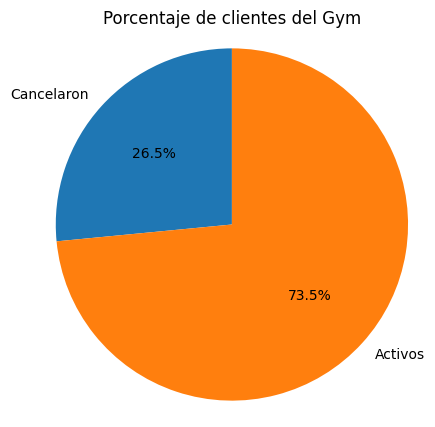

In [ ]:
#Grafica de cancelacion
#Etiquetas
labels = ["Cancelaron", "Activos"]

#Valores
sizes = [total_cancelaciones, total_activos]

#Crear gràfica
plt.figure(figsize=(5,5))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Porcentaje de clientes del Gym")
plt.axis("equal")
plt.show()

**Observaciones**

- El total de usuarios que cancelaron fueron 1061 personas y total de personas activas fue 2939

- Solo el 26.52% de los usuarios cancelaron subscripcion al gym y el 73.47% permanecen activos.

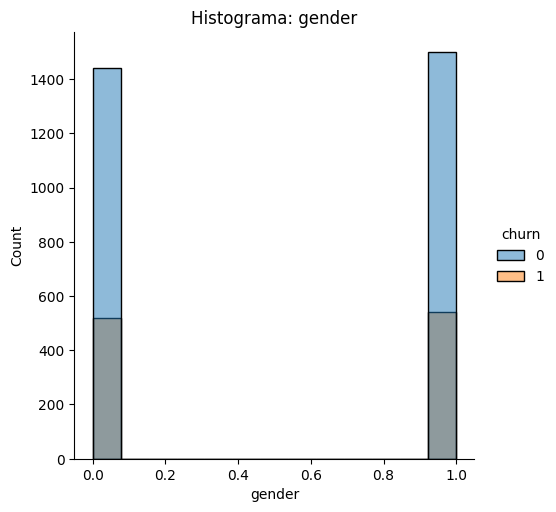

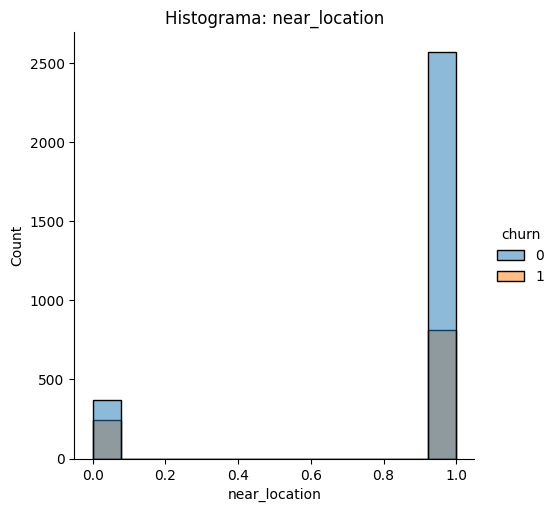

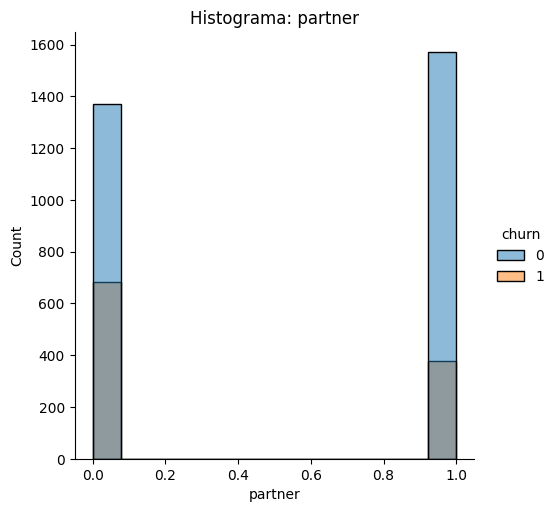

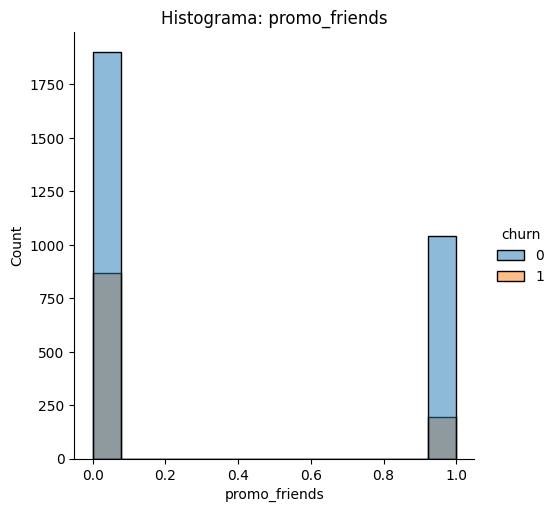

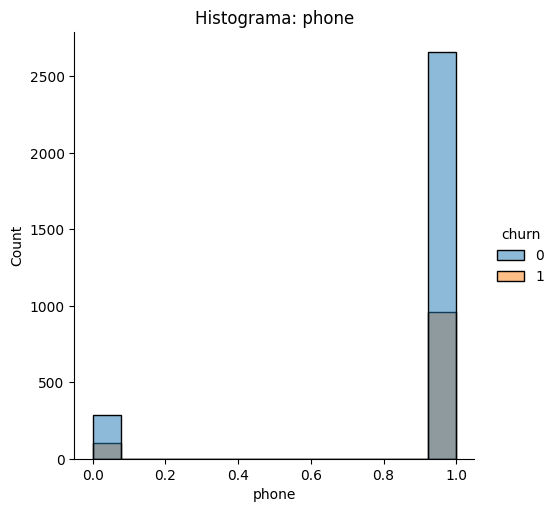

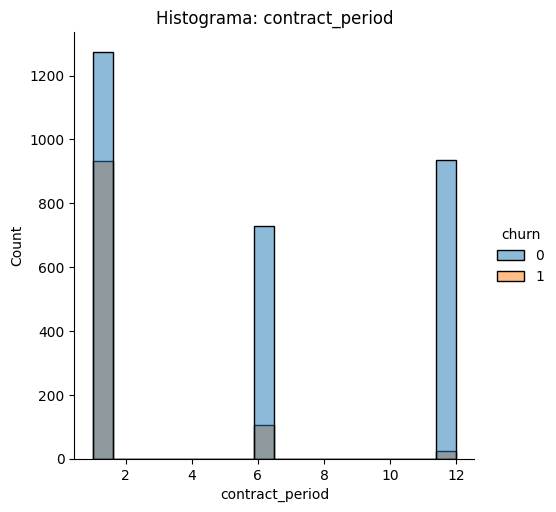

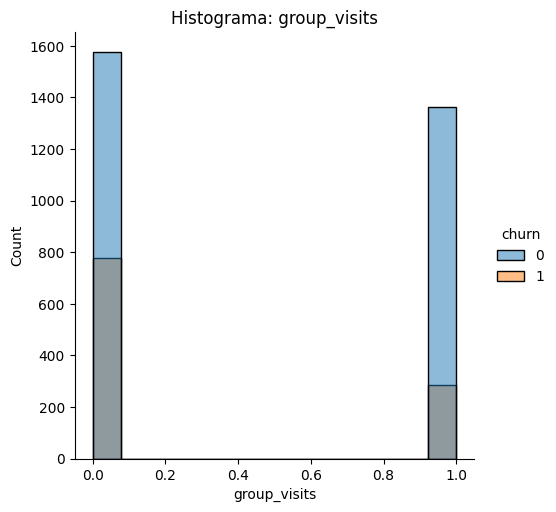

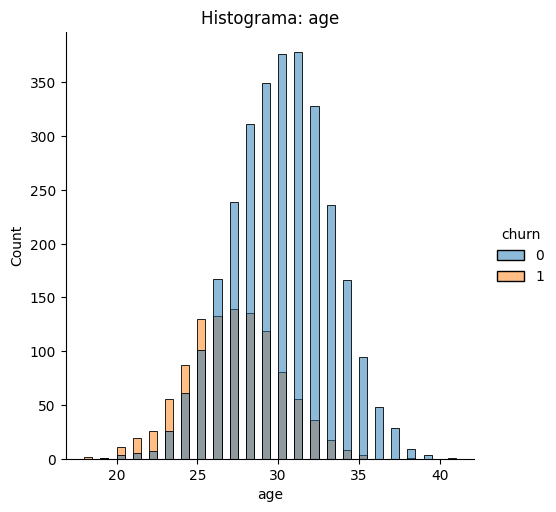

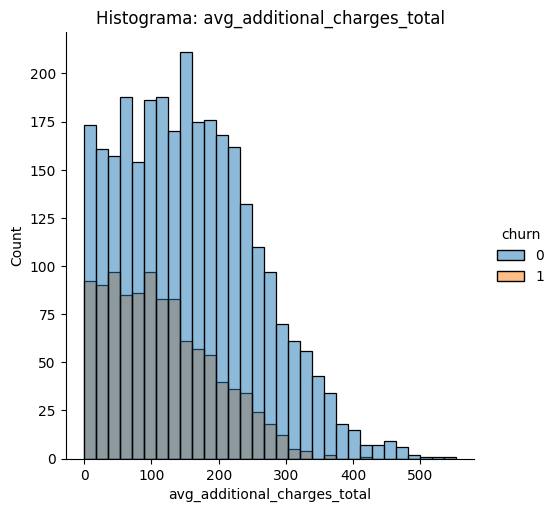

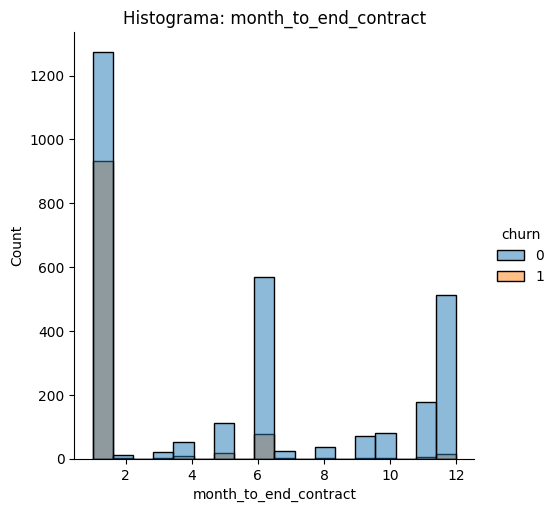

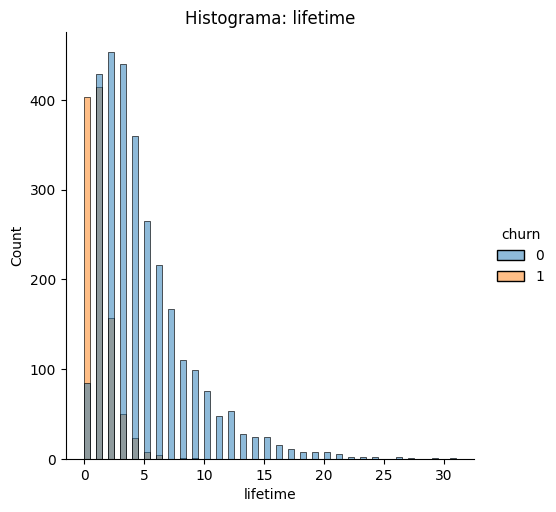

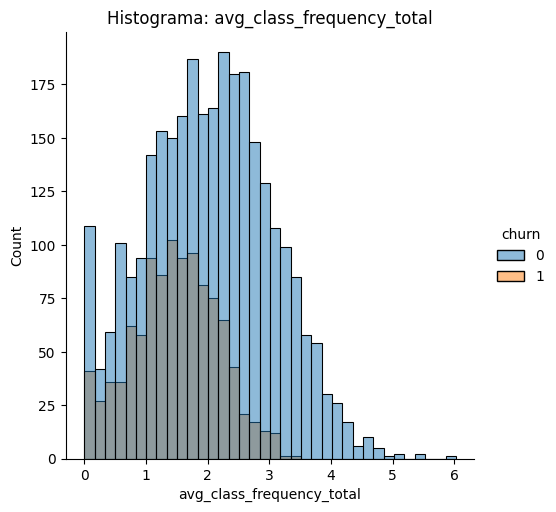

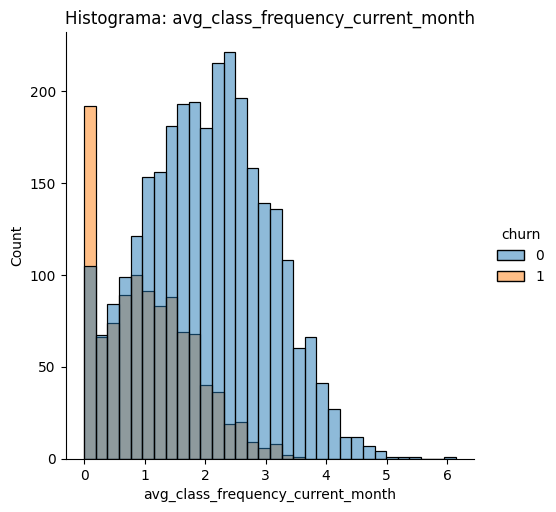

In [ ]:
#Trazar histograma que muestren la proporcion de cada categoria (variables categoricas 0/1 )

for column in df_gym.columns[:-1]:
    sns.displot(data=df_gym, x=column, hue='churn', kind="hist")
    plt.title(f'Histograma: {column}')
    plt.show()

**Observaciones**:

Variable **gender**: La cancelación en  mujeres(0) y hombres(1) se observan una distribución equivalente para ambos géneros.

Variable **near_location**: Se observa que la cancelación de los usuarios que viven lejos es mayor a los que viven cerca.

Variable **partner**: El número de clientes que cancelaron es mayor para los usuarios que no trabajan en una empresa asociada vs los que trabajan en una empresa asociada.

Variable **contract_period**: Hay mayor número de cancelaciones en el periodo de contrato de 1 mes.

Variable **group_visits**: Hay mayor nùmero de cancelaciones para los usuarios que no participan en clases grupales.

Variable **age**: El rango de edad de las personas que cancelaron es de 20 a 35 años, los clientes más jóvenes son los que más cancelan.

Variable **avg_additional_charges_total**: El promedio del monto de cargos adicionales para los clientes que cancelaron es de 115 usd, el promedio del monto de cargos adicionales para los que no cancelaron es mayor aproximadamente de 160 usd.

Variable **month_to_end_contract**: Para los usuarios que cancelan suelen estar a un mes antes de que se venza su contrato.

Variable **liftime**: El tiempo de vida de los clientes que cancelan es menor vs los que no cancelan.

Variable **avg_class_frequency_total**: El promedio para los clientes que cancelan es de 1 clase vs el promedio para los clientes que no cancelan es de 2 a 3 clases.

Variable **avg_class_frequency_current_month**:  En un mes en promedio los usuarios que cancelan no toman ninguna clase  grupal, por lo contrario, en un mes en promedio los usuarios que no cancelan toman de 2 a 3 clases.


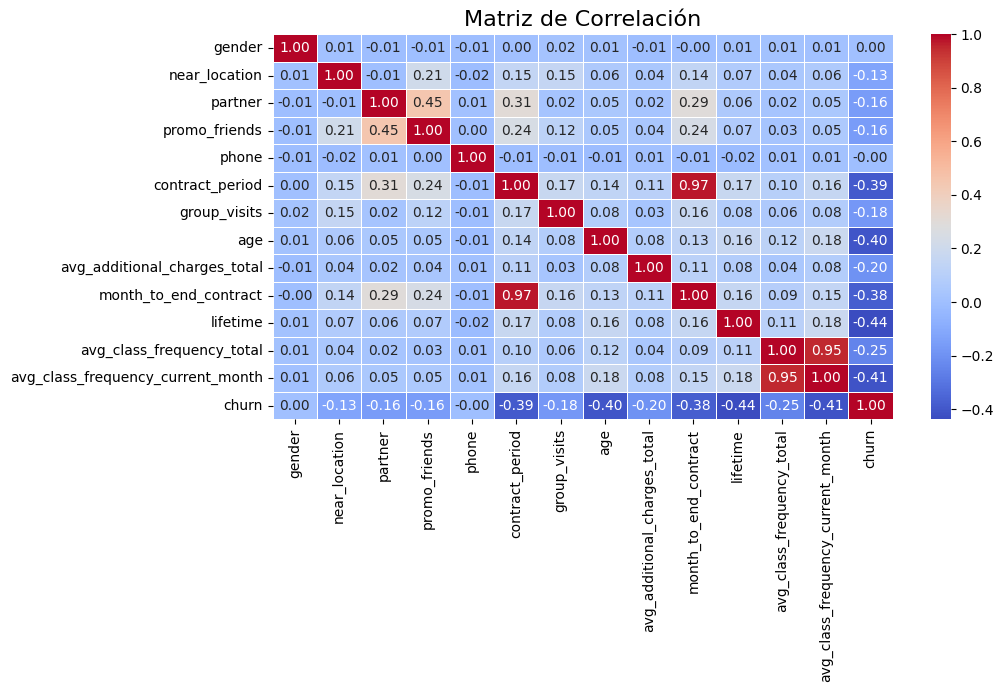

In [ ]:
#Crear una matriz de correlacion
corr_gym = df_gym.corr()

#Crear un mapa de calor para la matriz de correlacion
plt.figure(figsize=(10,5))

sns.heatmap(
    corr_gym,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    cbar=True
)

plt.title("Matriz de Correlación", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

**Observaciones**
- La variable **"partner"** tiene correlaciòn con la variable **"promo_friends"**, de las personas que trabajan en una empresa asociada pueden invitar a personas al gymnasio.

- La variable **"contract_period"** tiene correlaciòn con la variable **"month_to_end_contract"**

- La variable **"avg_class_current_month"** y **"avg_class_frecuency_total"** tiene una metrica de correlaciòn del 0.95 esto indica que la variables tienen una **multicolinealidad**



# Modelo de predicción

In [ ]:
#Dividir los datos de entrenamiento y prueba 80/20
#Crear una variable objetivo (y) y la matriz de caracteristicas (x)

y = df_gym["churn"]
X = df_gym.drop("churn", axis = 1)


In [ ]:
#Dividir los datos en conjunto de entrenamiento y validacion utilizando utilizando la funcion train_test_split()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [ ]:
#Entrenar el modelo en el set de entrenamiento con dos metodos: Regresión Logística y Bosque Aleatorio.

#Algorito de Regresión Logística - Estandarizar los datos
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)


**Entrenamiento del modelo de Regresion Logistica**

---



In [ ]:
#usar el mètodo de Regresión Logística
model_logistic = LogisticRegression(random_state=0)
model_logistic.fit(X_train_scaler, y_train)

#Utilizar el modelo entrenado para hacer predicciones
predic_log = model_logistic.predict(X_test_scaler)

**Entrenamiento del modelo del Bosque Aleatorio**


In [ ]:
#Algoritmo de Bosque Aleatorio
model_forest = RandomForestClassifier(n_estimators=100, random_state=0)
model_forest.fit(X_train_scaler, y_train)

#Utilizar el modelo entrenado para hacer predicciones
predic_forest = model_forest.predict(X_test_scaler)


**Métricas para Evaluar el Modelo**




In [ ]:
#Funcion para observar las metricas de evaluacion del modelo
def print_all_metrics(y_test, predicciones):
    print("Exactitud:{:.2f}".format(accuracy_score(y_test, predicciones)))
    print("Precisión:{:.2f}".format(precision_score(y_test, predicciones)))
    print("Recall:{:.2f}".format(recall_score(y_test, predicciones)))

In [ ]:
#Llamar a la funcion
#Mètricas para el Modelo de Regresion Logistica
print("Mètricas de Regresion Logistica")
print_all_metrics(y_test, predic_log)

print("-" * 50)

#Mètricas para el Modelo de Bosque Aleatorio
print("Mètricas del Bosque Aleatorio")
print_all_metrics(y_test, predic_forest)

Mètricas de Regresion Logistica
Exactitud:0.92
Precisión:0.85
Recall:0.83
--------------------------------------------------
Mètricas del Bosque Aleatorio
Exactitud:0.92
Precisión:0.84
Recall:0.81


**Observaciones**:

**Las mètricas de Regresion Logistica**:

 **Exactitud**: El modelo acierta en 9 de cada 10 predicciones.

 **Precision**: De todas las redes que el modelo predice como "inestables", el 92% realmente lo son. Esto significa que tiene un 8% de falsas alarmas.

 **Recall**: El modelo detecta correctamente el 83% de las redes que realmente son inestables. Esto significa que se le escapan 2 de cada 10 redes inestables.







**Las mètricas de Bosque Aleatorio**:

 **Exactitud**: El modelo acierta en 9 de cada 10 predicciones.


 **Precision**: De todas las redes que el modelo predice como "inestables", el 87% realmente lo son. Esto significa que tiene un 13% de falsas alarmas.


 **Recall**: El modelo detecta correctamente el 79% de las redes que realmente son inestables. Esto significa que se le escapan 2 de cada 10 redes inestables.

-Observando las mètricas se puede observar que el Modelo de Regresion Logistica es mejor que el Modelo de Bosque Aleatorio detectanto mejor  exactitud y menos falsas alarmas.

**Clustering**

In [ ]:
#Entrenar y transformar las variables de caracteristicas
x_scl = scaler.fit_transform(X)

#print(x_scl[:10])

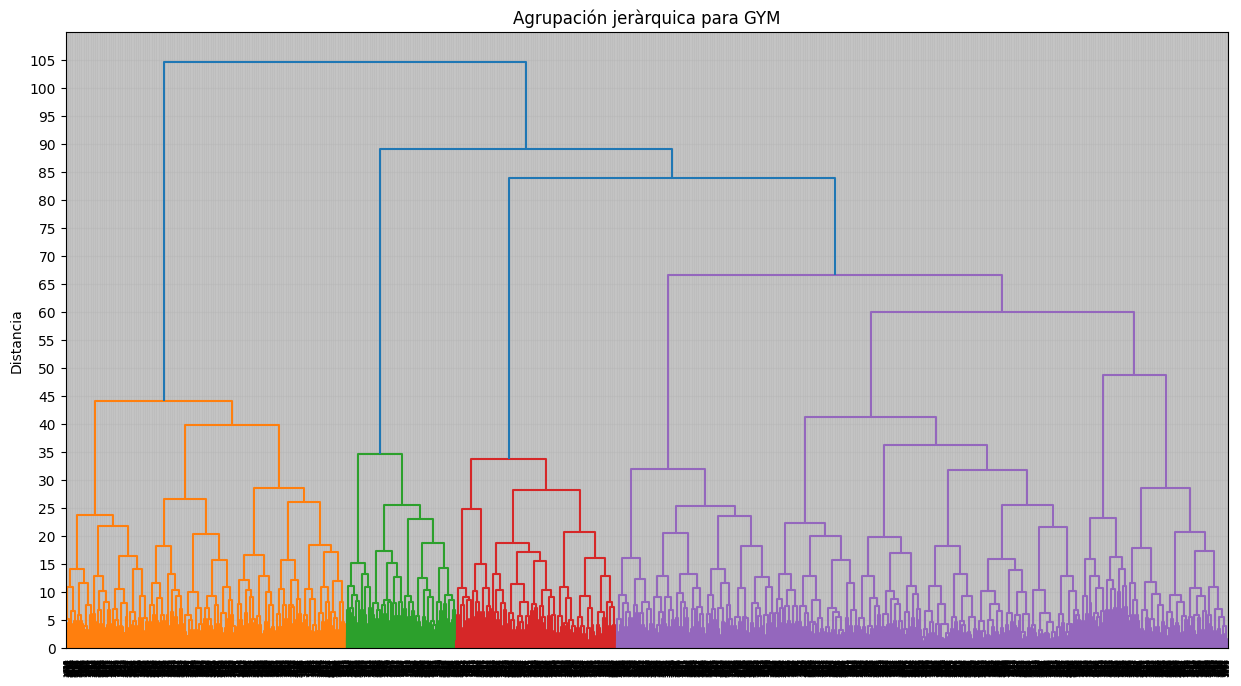

In [ ]:
#Utiliza la función linkage() para crear una matriz de distancias basada en la matriz de características estandarizada
linked = linkage(x_scl, method = "ward")


#trazar un dendrograma
plt.figure(figsize=(15, 8))
dendrogram(linked, orientation="top")
plt.title("Agrupación jeràrquica para GYM")

plt.yticks(range(0, 110, 5))
plt.ylabel('Distancia')
plt.grid(True, alpha=0.3)

plt.show()


**Observaciones**

- El algoritmo sugirio 4 clusters principales; naranja, verde, rojo, morado que representa un tipo de cliente del gym

- En el cluster 4 se puede subdividir o dividir en otro cluster.

In [ ]:
#Entrenar el modelo de clustering con el algoritmo k-mens
km = KMeans(n_clusters = 5)
labels = km.fit_predict(x_scl)

In [ ]:
#Mirar los valores medios de caracteristicas para los Clùsters
df_gym["cluster"] = labels

cluster_mean = df_gym.groupby("cluster").mean().round(0).reset_index(drop=True)
cluster_mean.index += 1
cluster_mean

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
1,0.0,1.0,1.0,1.0,1.0,3.0,0.0,29.0,140.0,3.0,4.0,2.0,2.0,0.0
2,0.0,0.0,0.0,0.0,1.0,2.0,0.0,28.0,134.0,2.0,3.0,2.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,2.0,0.0,28.0,131.0,2.0,2.0,1.0,1.0,1.0
4,1.0,1.0,1.0,0.0,1.0,12.0,1.0,30.0,165.0,11.0,5.0,2.0,2.0,0.0
5,1.0,1.0,0.0,0.0,1.0,3.0,0.0,30.0,163.0,3.0,5.0,3.0,3.0,0.0


**Observaciones**

- El **cluster 1** la  edad promedio es de 28 años, la frecuencia media de visitas es de 1 a 2 veces por semana, la cantidad  de dinero promedio gastado es de 144, el tiempo promedio que llevan en el gymnasio es de 4 meses.

- El **cluster 2** la edad promedio es de 28 años, la frecuencia media de visitas es de 1 vez por semana, la cantidad de dinero promedio gastado es de 131, el tiempo promedio que llevan  en el gymnasio es de 2 meses.

- EL **cluster 3** la edad promedio es de 28 años, la frecuencia media de visitas es de 2 a 3 veces por semana, la cantidad de dinero promedio gastado es de 161, el tiempo promedio que llevan en el gymnasio es de 5 meses.

- El **cluster 4** la edad promedio es de 30 años, la frecuencia media de visitas es de 1 a 2 veces por semana, la cantiad de dinero promedio gastado es de 160, el tiempo promedio que llevan en el gymnasio es de 4 a 5 meses.


- El **cluster 5** la edad promedio es de 30 años, la frecuencia media de visitas es de 1 a 2 veces por semana, la cantidad de dinero promedio gastado es de 135, el tiempo promedio que llevan en el gymnasio es de 2 a 3 meses.

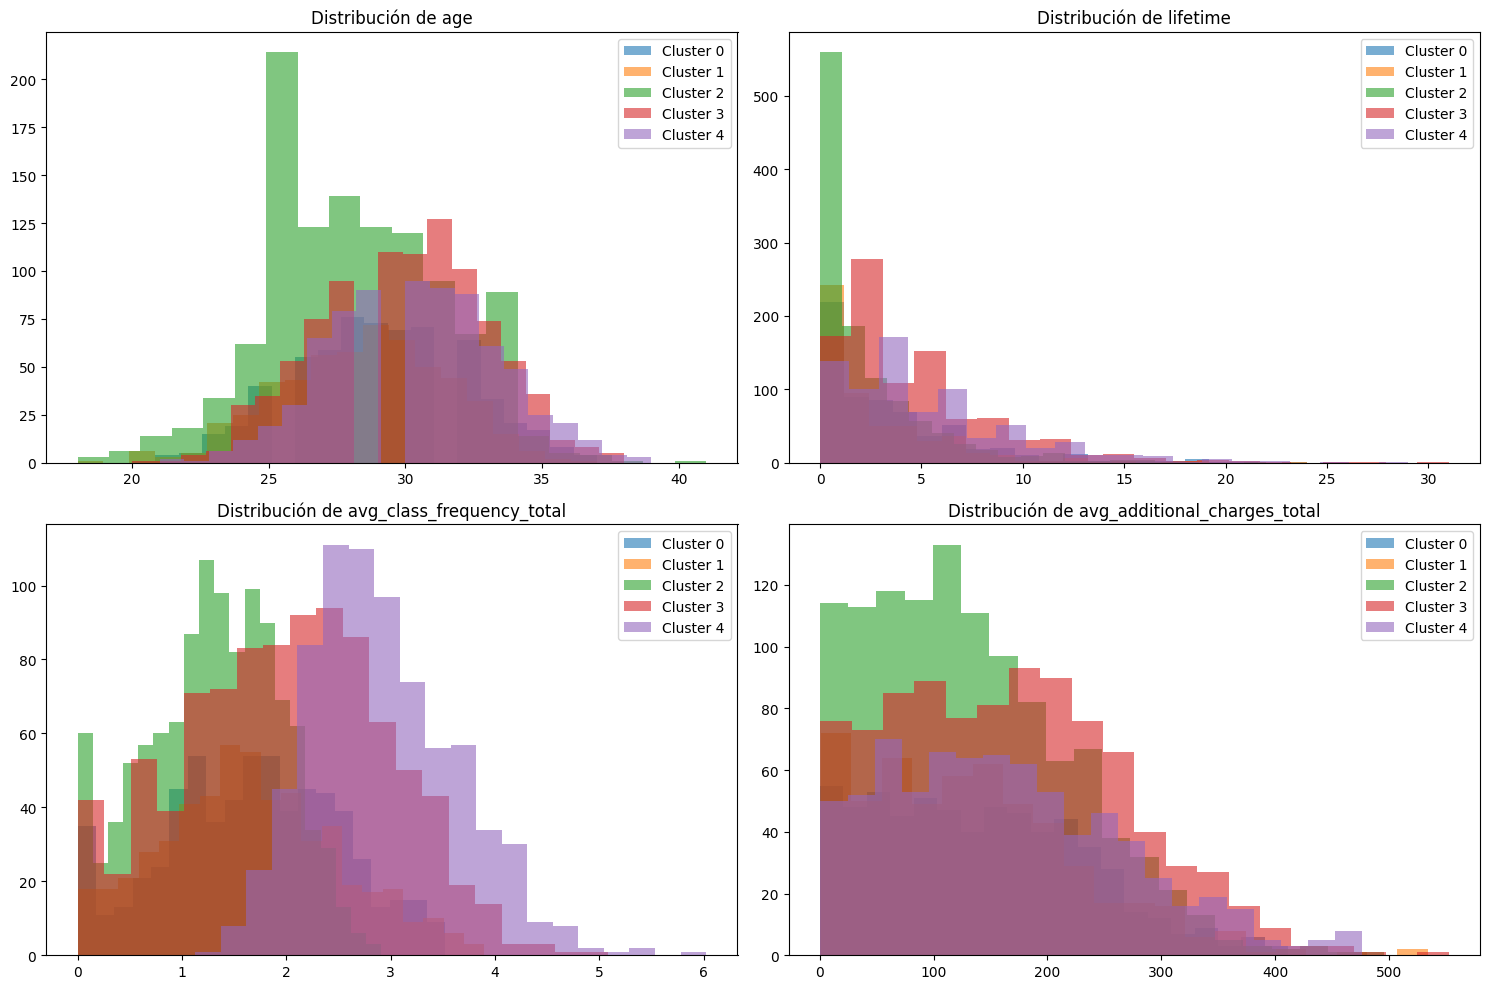

In [ ]:
# Para cada característica, crear histogramas por cluster
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
caracteristicas = ['age', 'lifetime', 'avg_class_frequency_total', 'avg_additional_charges_total']

for i, caracteristica in enumerate(caracteristicas):
    ax = axes[i//2, i%2]
    for cluster in range(5):  # Asumiendo 5 clusters
        cluster_data = df_gym[df_gym['cluster'] == cluster][caracteristica]
        ax.hist(cluster_data, alpha=0.6, label=f'Cluster {cluster}', bins=20)

    ax.set_title(f'Distribución de {caracteristica}')
    ax.legend()

plt.tight_layout()
plt.show()

**Observaciones**

-En el histograma  de edad se puede observar que hay un rango promedio para todos los cluster de 25 a 35 años, el cluster 1 tiene personas mas jóvenes de 25 a 30 años.

-En el histograma de tiempo de antigüedad el cluster 1 tiene poca tasa de antigüedad, el cluster 2 y 3 los clientes tienen màs antigüedad

-En el histograma de frecuencia de visitas por semana el cluster 2 y 3  son los màs activos.

-En el histograma cantidad total de dinero gastado el cluster 2 y 3 son los que tienen mayor gasto, el cluster 1 es el que menos tiene gasto.

In [ ]:
#Calcular la tasa de cancelacion para cada cluster
tasa_cancelacion = df_gym.groupby("cluster")["churn"].agg(["count", "sum", "mean"]).reset_index(drop=True)
tasa_cancelacion.index +=1
tasa_cancelacion.columns = ["total clientes", "cancelaciones", "tasa de cancelacion"]
tasa_cancelacion["%_tasa_cancelacion"] = (tasa_cancelacion["tasa de cancelacion"] * 100).round(0)

tasa_cancelacion.sort_values(by="%_tasa_cancelacion", ascending=False)

,total clientes,cancelaciones,tasa de cancelacion,%_tasa_cancelacion
3,1132,585,0.516784,52.0
2,546,245,0.448718,45.0
1,634,167,0.263407,26.0
5,753,43,0.057105,6.0
4,935,21,0.022460,2.0


**Observaciones**:

- El **cluster 1** tiene 634 clientes, 167 clientes cancelaron  y tiene  una tasa de cancelaciòn del 26%

- El **cluster 2** tiene 546 clientes, 245 clientes cancelaron y es uno de los cluster con mayor tasa de cancelacion del 45%

- El **cluster 3** tiene 1132 clientes, 585 clientes cancelaron y tiene una tasa de cancelacion màs del 52%

- El **cluster 4** tiene 935 clientes, 21 clientes cancelaron y tiene la tasa de cancelacion del 6%

- El **cluster 5** tiene 753 clientes, 43 cancelaciones y con una  tasa de cancelacion  alta del 2%

- Los grupos que son màs propensos a irse son el cluster 3 y 2, los clusters que son màs leales son el cluster 5 y 4.


***Conclusiones***

- Todos los clusters tienen un rango de edad promedio de 25 a 35 años.

- En el **cluster 1** la frecuencia de visitas es baja, el dinero de gasto es medio de 144,  tiene una antigüedad alta de 4 meses en promedio  y  la tasa de cancelación es baja del 27%  se pueden clasificar como **clientes promedio**.

- En el **cluster 2** la frecuencia de visitas es baja, la cantidad de dinero gastado es bajo de 131, tiene poca antigüedad de 2 meses en promedio, y la tasa de cancelación es la màs alta del 45% se pueden clasificar como **clientes perdidos o en riesgo**.

- En el **cluster 3** la frecuencia de visitas es alta, la cantidad de dinero gastado es alta de 161, el tiempo de antigüedad de 5 meses en promedio y a tasa de cancelación es baja del 52% se pueden clasificar como   **clientes débiles**

- En el **cluster 4** la frecuencia de visitas es media, la cantidad de dinero gastado es alto de 160, el tiempo de antigüedad es alta de 4 a 5 meses en promedio, tiene la menor tasa de cancelación del 2% se pueden clasificar como **clientes valiosos**.

- En el **cluster 5** La frecuencia de visitas es media, la cantidad de dinero es baja de 135, el tiempo promedio de antigüedad es de baja de 2 a 3 meses en  promedio y  su tasa de cancelación es alta del 6% se pueden clasificar como **clientes màs activos**.


- Los cluster màs valiosos para el gymnasio Model Fitness es 4 y 5, atraen más dinero a la empresa, son más activos y son clientes leales.

***Recomendaciones***
- El cluster 2 (clientes perdidos y en riesgo) y el cluster 3 (clientes débiles) tienen una alta tasa de cancelación, para este tipo de clientes se les puede ofrecer un descuento de estudiantes ya que los clientes más jóvenes son lo que suelen cancelar más, se les puede ofrecer una promoción al invitar a un amigo o familiar, invitarlos a tomar clases grupales o tener un horario más amplio para tomar clases grupales en el gimnasio, ya que representa un factor de cancelación para los que no toman clases grupales.
